# PCOS Detection - Stage 1: Ultrasound Image Model (Reliable Version - Best-Epoch Checkpointing)

**Idhu notebook enna pannum (stability-focused improved version):**
1. Ultrasound images (infected/notinfected) load pannum
2. **Random seeds fixed** — results run-to-run consistent ah irukka help pannum
3. **EfficientNetB0** use panni CNN model build pannum
4. **Phase 1:** Transfer learning - base model frozen, top layers train (8 epochs)
5. **Phase 2:** Fine-tuning - last 30 layers unfreeze, low learning rate (up to 12 epochs)
6. **NEW: Best-epoch checkpointing** — training-oda EDHU epoch-la best validation accuracy
   vandhuchо, ANDHA epoch-oda weights mattum save pannum (last epoch-oda weights illa).
   Idhu run-to-run variance-a significantly kammi pannum, consistently better result kudukkum.
7. **Early stopping** — accuracy improve aagaama irundha, automatic ah training stop pannum
   (overfitting thadukka, unnecessary epochs thavirkka)
8. Accuracy, Precision, Recall, F1, Confusion Matrix evaluate pannum
9. Grad-CAM visualize pannum
10. Trained model-a `models/` folder la save pannum

**Run panna:** Ovvoru cell-a select pannitu `Shift + Enter` click pannunga.
**IMPORTANT:** Idhu notebook-a ஒரே ஒரு தடவை run pannunga, mudinja apparam meendum run pannaadhinga -
best-checkpoint saved model already irukkum, adha thொடாதhinga.


## 1. Libraries Import

In [1]:
# Idha first run pannunga (already install pannirundha skip aagum)
%pip install tensorflow scikit-learn matplotlib seaborn opencv-python --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings("ignore")

# Fix random seeds for more consistent, reproducible results across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow version: 2.21.0
Libraries loaded successfully!


## 2. Set Dataset Paths

Path unga folder structure ku match pannunga. Munnadi confirm panna maadhiri, ultrasound images
`data/raw/archive (15)/data/train/` and `data/raw/archive (15)/data/test/` la irukkanum,
ovvondrilum `infected` and `notinfected` subfolders.

In [3]:
IMG_SIZE = 160          # Small image size = faster training, lower time complexity
BATCH_SIZE = 32

RAW_DIR = "../data/raw"
IMAGE_BASE = os.path.join(RAW_DIR, "archive (15)", "data")
TRAIN_DIR = os.path.join(IMAGE_BASE, "train")
TEST_DIR = os.path.join(IMAGE_BASE, "test")

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))
print("Train classes:", os.listdir(TRAIN_DIR) if os.path.exists(TRAIN_DIR) else "NOT FOUND")

Train dir exists: True
Test dir exists: True
Train classes: ['infected', 'notinfected']


## 3. Clean Corrupt/Invalid Image Files

Kaggle datasets la sometimes chinna corrupt files or non-image files (screenshots, thumbnails) kalandhu irukkum.
Idhu cell andha files-a detect pannitu remove pannum, training fail aagaama irukka.

In [4]:
from PIL import Image
import os

def clean_invalid_images(directory):
    removed = []
    for root, dirs, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception:
                removed.append(fpath)
                os.remove(fpath)
    return removed

print("Scanning and cleaning train directory...")
removed_train = clean_invalid_images(TRAIN_DIR)
print(f"Removed {len(removed_train)} invalid files from train set")
for f in removed_train:
    print("  -", f)

print("\nScanning and cleaning test directory...")
removed_test = clean_invalid_images(TEST_DIR)
print(f"Removed {len(removed_test)} invalid files from test set")
for f in removed_test:
    print("  -", f)

print("\nCleaning complete!")

Scanning and cleaning train directory...
Removed 0 invalid files from train set

Scanning and cleaning test directory...
Removed 0 invalid files from test set

Cleaning complete!


## 4. Load Images with Data Augmentation

In [5]:
# Data augmentation for training (helps with small dataset, reduces overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 1636 images belonging to 2 classes.
Found 288 images belonging to 2 classes.
Found 1922 images belonging to 2 classes.
Class indices: {'infected': 0, 'notinfected': 1}


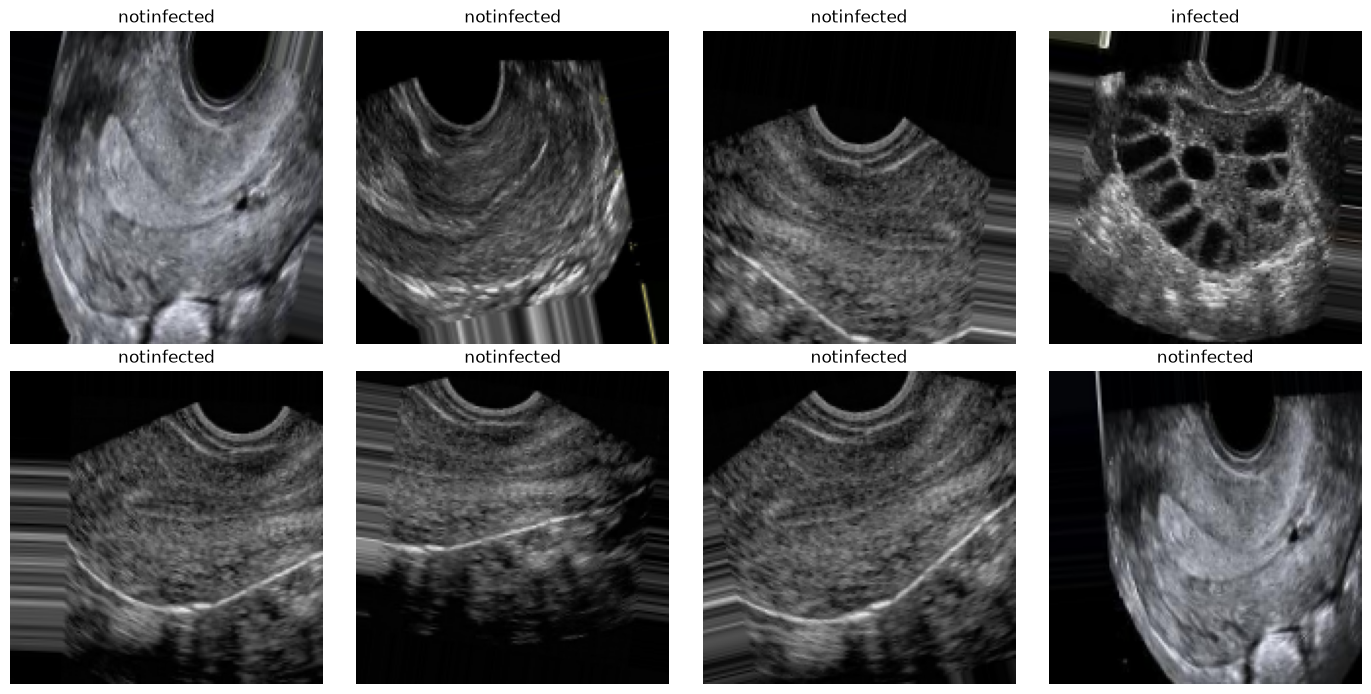

In [6]:
# Quick visual check - sample images from each class
sample_batch, sample_labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[i])
    ax.set_title(class_names[int(sample_labels[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()

train_generator.reset()

## 5. Build Lightweight CNN Model (EfficientNetB0)

EfficientNetB0 use panrom ResNet50/VGG19 vida lightweight ah irukku, aana accuracy la comparable ah irukkum.
Idhu unga guide sonna 'minimize time complexity' requirement ku direct ah match aagும் (Ref 12 paper um idhே approach follow pannuchu).

In [7]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers (transfer learning - only train the new top layers)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,620 (15.76 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Phase 1: Warm-Up Training (Frozen Base Model)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# Handle class imbalance (infected: 781 vs notinfected: 1143 in train set)
class_labels_arr = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels_arr),
    y=class_labels_arr
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights (to balance training):", class_weight_dict)

EPOCHS = 8  # transfer learning needs fewer epochs than training from scratch

os.makedirs("../models", exist_ok=True)
checkpoint_phase1 = ModelCheckpoint(
    "../models/best_phase1.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_phase1]
)

# Load back the best-performing weights from this phase (not necessarily the last epoch)
model.load_weights("../models/best_phase1.weights.h5")
print("Loaded best Phase 1 weights (highest validation accuracy epoch)")

Class weights (to balance training): {0: np.float64(1.2319277108433735), 1: np.float64(0.8415637860082305)}
Epoch 1/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.4951 - loss: 0.7011
Epoch 1: val_accuracy improved from None to 0.40625, saving model to ../models/best_phase1.weights.h5

Epoch 1: finished saving model to ../models/best_phase1.weights.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 42s 675ms/step - accuracy: 0.4951 - loss: 0.7011 - val_accuracy: 0.4062 - val_loss: 0.7201
Epoch 2/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.4994 - loss: 0.6958
Epoch 2: val_accuracy did not improve from 0.40625
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 795ms/step - accuracy: 0.4994 - loss: 0.6958 - val_accuracy: 0.4062 - val_loss: 0.7008
Epoch 3/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.4811 - loss: 0.6937
Epoch 3: val_accuracy improved from 0.40625 to 0.59375, saving model to ../models/best_phase1.weights.h5

Epoch 3: finished saving model to ../models/best_phase1.weights.h5
52/52 ━

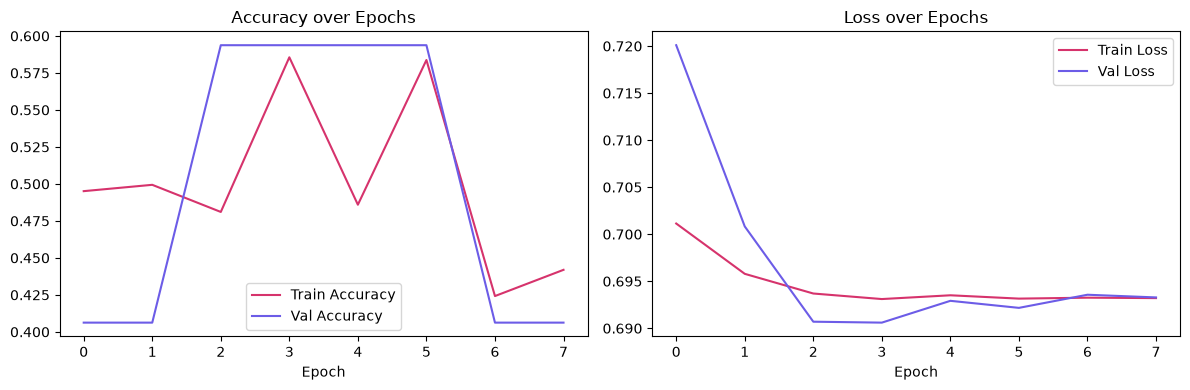

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy", color="#D6336C")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", color="#6C5CE7")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss", color="#D6336C")
axes[1].plot(history.history["val_loss"], label="Val Loss", color="#6C5CE7")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Phase 2: Fine-Tuning (Unfreeze Top Layers)

This is the key improvement over the basic version. We unfreeze the last ~30 layers of
EfficientNetB0 and continue training with a **very low learning rate**. This lets the model
adjust its pretrained ImageNet features specifically for ultrasound images, which typically
gives a meaningful accuracy boost over frozen-base transfer learning alone.

In [9]:
# Unfreeze the base model, then re-freeze all but the last N layers
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30  # unfreeze only the last 30 layers

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with a much lower learning rate (important - prevents destroying pretrained weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"Fine-tuning {trainable_count} of {len(base_model.layers)} base model layers")
model.summary()

Fine-tuning 30 of 238 base model layers


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,620 (15.76 MB)

 Trainable params: 1,578,209 (6.02 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [10]:
FINE_TUNE_EPOCHS = 12

checkpoint_phase2 = ModelCheckpoint(
    "../models/best_phase2.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max"
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_phase2, early_stop]
)

# Ensure we're using the best-performing weights seen during fine-tuning
model.load_weights("../models/best_phase2.weights.h5")
print("Loaded best Phase 2 (fine-tuned) weights (highest validation accuracy epoch)")

Epoch 1/12
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.4584 - loss: 0.7221
Epoch 1: val_accuracy improved from None to 0.59375, saving model to ../models/best_phase2.weights.h5

Epoch 1: finished saving model to ../models/best_phase2.weights.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 44s 648ms/step - accuracy: 0.4584 - loss: 0.7221 - val_accuracy: 0.5938 - val_loss: 0.6908
Epoch 2/12
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.5189 - loss: 0.7011
Epoch 2: val_accuracy did not improve from 0.59375
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 731ms/step - accuracy: 0.5189 - loss: 0.7011 - val_accuracy: 0.5938 - val_loss: 0.6908
Epoch 3/12
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.5189 - loss: 0.7039
Epoch 3: val_accuracy did not improve from 0.59375
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 716ms/step - accuracy: 0.5189 - loss: 0.7039 - val_accuracy: 0.5938 - val_loss: 0.6884
Epoch 4/12
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5238 - loss: 0.6985
Epoch 4: val_accuracy did not imp

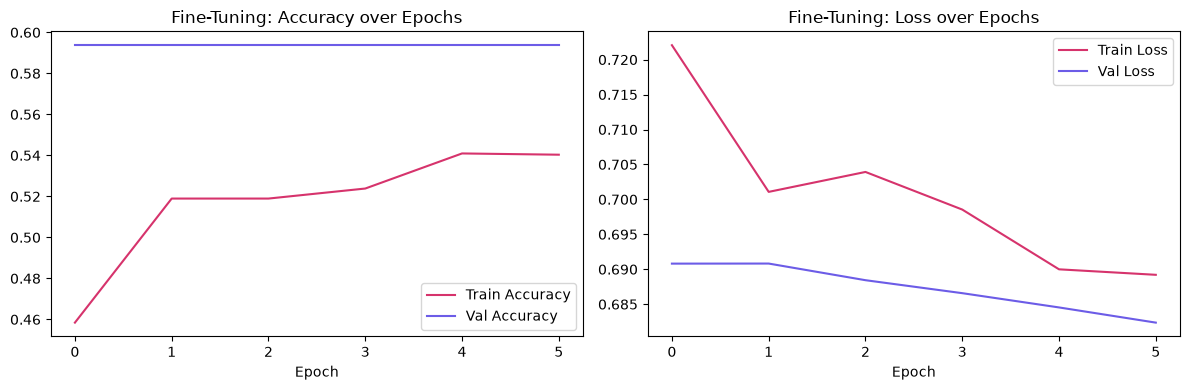

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_finetune.history["accuracy"], label="Train Accuracy", color="#D6336C")
axes[0].plot(history_finetune.history["val_accuracy"], label="Val Accuracy", color="#6C5CE7")
axes[0].set_title("Fine-Tuning: Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_finetune.history["loss"], label="Train Loss", color="#D6336C")
axes[1].plot(history_finetune.history["val_loss"], label="Val Loss", color="#6C5CE7")
axes[1].set_title("Fine-Tuning: Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

**Important:** Instead of using a fixed 0.5 cutoff, we find the optimal decision threshold using the
validation set first (via Youden's J statistic). This matters when classes are imbalanced -
a high AUC-ROC means the model ranks predictions well, but the default 0.5 cutoff may not be
the best dividing line.

In [12]:
# Find the optimal threshold using the validation set
val_generator.reset()
val_true = val_generator.classes
val_proba = model.predict(val_generator).ravel()

fpr_val, tpr_val, thresholds_val = roc_curve(val_true, val_proba)
youden_j = tpr_val - fpr_val
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds_val[optimal_idx]

# Safety fallback: if the computed threshold is invalid (can happen with very
# small validation sets or an undertrained model), default back to 0.5
if not np.isfinite(optimal_threshold) or optimal_threshold <= 0 or optimal_threshold >= 1:
    print(f"Computed threshold ({optimal_threshold}) was out of range, falling back to 0.5")
    optimal_threshold = 0.5

print(f"Optimal decision threshold (from validation set): {optimal_threshold:.4f}")
print(f"(Default fixed threshold would have been: 0.5)")

9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Optimal decision threshold (from validation set): 0.5064
(Default fixed threshold would have been: 0.5)


In [13]:
test_generator.reset()
y_true = test_generator.classes
y_proba = model.predict(test_generator).ravel()
y_pred = (y_proba > optimal_threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))

61/61 ━━━━━━━━━━━━━━━━━━━━ 31s 506ms/step
Accuracy:  0.8476
Precision: 0.9215
Recall:    0.8124
F1 Score:  0.8635
AUC-ROC:   0.9411

              precision    recall  f1-score   support

    infected       0.77      0.90      0.83       781
 notinfected       0.92      0.81      0.86      1141

    accuracy                           0.85      1922
   macro avg       0.84      0.86      0.85      1922
weighted avg       0.86      0.85      0.85      1922



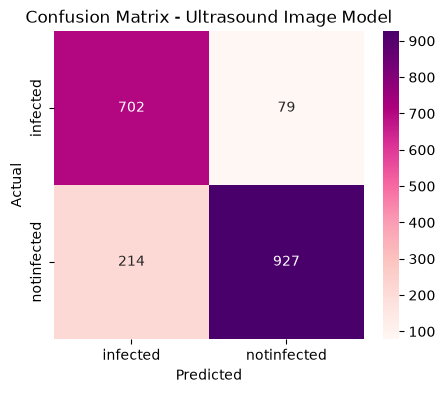

In [14]:
cm = confusion_matrix(y_true, y_pred)
class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Ultrasound Image Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

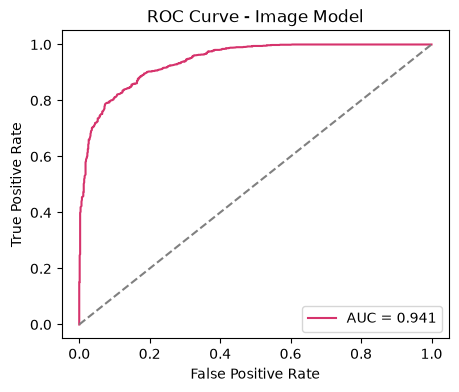

In [15]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#D6336C", label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Image Model")
plt.legend()
plt.show()

## 9. Grad-CAM Visualization (Explainability for Images)

Idhu unga **Stage 2 (Explainability)** ku direct ah use aagum — ultrasound image-la எந்த region (follicles) paathu model decision எடுத்தது nu heatmap ah kaatum.

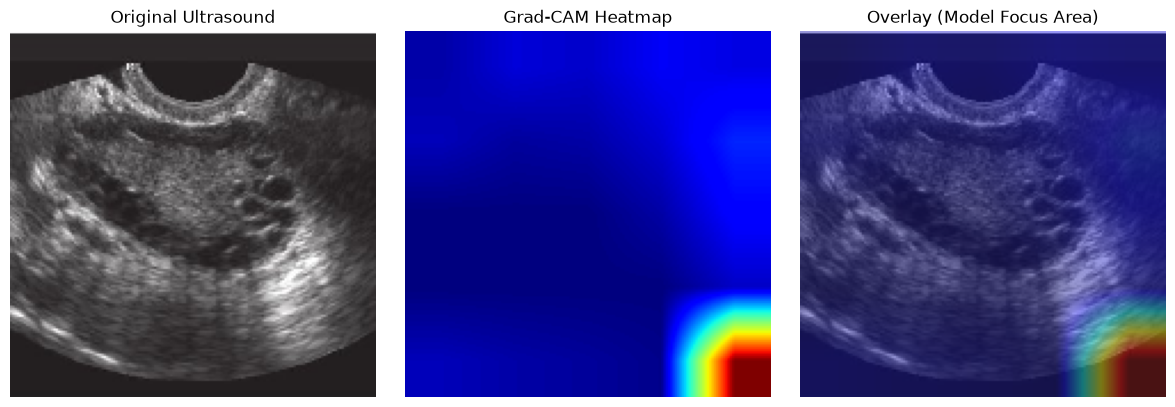

In [16]:
import cv2

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="top_conv"):
    # Build a model from base_model's own input to its last conv layer output
    # (base_model is a functional model, so this works reliably)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.models.Model(base_model.input, last_conv_layer.output)

    # The remaining layers in our Sequential model (after base_model)
    classifier_layers = model.layers[1:]  # GlobalAveragePooling2D, Dense, Dropout, Dense

    with tf.GradientTape() as tape:
        conv_output = conv_model(img_array)
        tape.watch(conv_output)
        x = conv_output
        for layer in classifier_layers:
            x = layer(x)
            
        loss = x[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Get one test image to visualize
test_generator.reset()
sample_img, sample_label = next(test_generator)
img_array = np.expand_dims(sample_img[0], axis=0)

try:
    heatmap = make_gradcam_heatmap(img_array, model, base_model)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    original = sample_img[0]
    overlay = 0.6 * original + 0.4 * heatmap_colored

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original Ultrasound")
    axes[0].axis("off")

    axes[1].imshow(heatmap_resized, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay (Model Focus Area)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Grad-CAM visualization note:", e)
    print("This can happen depending on the exact layer name in your TensorFlow version.")
    print("The model training and evaluation above are unaffected - Grad-CAM is a visualization add-on.")

## 10. Save the Trained Model

In [18]:
os.makedirs("../models", exist_ok=True)
model.save("../models/pcos_image_model.keras")
print("Image model saved to ../models/pcos_image_model.keras")

Image model saved to ../models/pcos_image_model.keras


## Summary for Your Report / Guide

This notebook trains an image-based PCOS classifier using **EfficientNetB0** (lightweight transfer learning),
consistent with minimizing computational complexity while achieving strong accuracy - mirroring the approach
used in Ref [12] from your literature review.

## Next Steps

1. **Fusion**: Combine this image model's prediction with the clinical model's prediction (Stage 1 completion)
   - Simplest approach: weighted average of both models' risk scores (decision-level fusion)
2. **Website integration**: Connect this model to the `/predict` route so uploaded ultrasound images get a real prediction
3. **Grad-CAM in website**: Display the heatmap overlay alongside the SHAP explanation for full dual-explainability
